# AIoT Project 2 — Human Gesture Recognition
### Windowed Time-Series Classification using RF and 1D CNN

**University of Patras** | AIoT Course | May 2026

*Derekenaris Nikolaos · Mitrogiannis Evangelos · Stauridis Goulielmos Nikolaos*

---

This notebook implements a full end-to-end AIoT pipeline for recognising five 
smartphone gestures (**Scroll Up, Scroll Down, Swipe Left, Swipe Right, Texting**) 
from raw 6-axis IMU data collected via the MetaMotionR wrist-worn sensor kit.

Two classification approaches are evaluated and compared:
- **Random Forest on flattened windows** — a classical ML baseline that collapses the temporal dimension into a feature vector
- **1D CNN on raw windows** — a deep learning model that preserves and learns directly from the temporal structure of the signal

Models are assessed under three evaluation protocols of increasing strictness:
**5-fold CV → LOSO CV → True unseen test set**, to separate within-cohort 
performance from real cross-subject generalisation.

In [21]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder

# db
import pymongo
from bson import ObjectId

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values
from utils import subtract_mean

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca
from utils_visual import plot_bar
from utils_visual import plot_distribution_analysis

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Start time of execution

In [22]:
time_start = time()

## Load configuration

In [23]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [24]:
axes = config['rename']
print(axes)

['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']


In [25]:
client = pymongo.MongoClient(config["client"])

In [26]:
db = client[config["db"]]
coll = db[config["col"]]

In [27]:
found_keys = coll.distinct("_id")
print(f'Found {len(found_keys)} keys in the collection')

Found 90 keys in the collection


## Load data

We load two seperate sets, the **train/val split**, consisting of 75 mins (3 subjects * 5 one-minute recordings * 5 Gestures)
And a **testing set** which we set aside for the final evaluation

In [28]:
# scroll up data
# results = list(coll.find({"gesture_id": "scroll-up-index"}, {"data": True, "gesture_id": True}))
results = list(coll.find({"test": {"$exists": False}}, {"data": True, "gesture_id": True, 'user': True}))
print(f'Found {len(results)} keys in the collection')

test_results = list(coll.find({"test": {"$exists": True}}, {"data": True, "gesture_id": True, 'user': True}))
print(f'Found {len(test_results)} TESTING keys in the collection')

Found 75 keys in the collection
Found 15 TESTING keys in the collection


In [29]:
print(results[0].keys())

dict_keys(['_id', 'data', 'gesture_id', 'user'])


In [30]:
def chop_edges_and_concat(results: list) -> dict:
    """This fuction takes the list of results from the database query, chops off the first and last 500 rows of data for each gesture instance, and concatenates the remaining data for each gesture_id into a single DataFrame. The resulting dictionary has gesture_ids as keys and their corresponding concatenated DataFrames as values.

    Args:
        results (list): the list of results from the database query, where each item is a dictionary containing 'data', 'gesture_id', and 'user'.

    Returns:
        dict: a dictionary where each key is a gesture_id and each value is a DataFrame containing the concatenated and edge-chopped data for that gesture.
    """
    all_chunks = pd.DataFrame(results)
    # print(len(all_chunks))

    ids = all_chunks['gesture_id'].unique().tolist()
    # print(ids)

    gestures = {}
    for id in ids:
        gesture_chunks = all_chunks[all_chunks['gesture_id'] == id]
        print(gesture_chunks.columns)
        current_data = gesture_chunks[['user', 'data']]
        
        chunks = []
        for chunk in current_data.itertuples():
            # print(type(chunk))
            # print(chunk)
            df = pd.DataFrame(chunk.data)
            df.drop(df.tail(500).index, inplace=True)
            df.drop(df.head(500).index, inplace=True)
            df['user'] = chunk.user
            chunks.append((id, df))

        joined_gesture = pd.concat([df for _, df in chunks], ignore_index=True)
        gestures[id] = joined_gesture

        # print(len(chunks[0][1]))
        # print(chunks[0][1].head())

        # print(len(joined_gesture))
        # print(joined_gesture.head())
    return gestures
    
    
# gestures = chop_edges_and_concat(results)
# print(len(gestures))
# print(gestures['scroll-up-index'])


## Cleaning

We Filter for Glitches/Outliers, this also handles missing values by interpolating them

In [31]:
def clean_sensor_outliers(df, window_size=50, threshold=3.0, axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']):
    """
    Cleans extreme hardware spikes using a Rolling Z-Score and Linear Interpolation.
    Assumes 100Hz data (window_size=50 is 0.5 seconds).
    """
    # copy of the og so we dont overwrite raw data
    df_clean = df.copy()
    
    sensor_columns = axes
    
    for col in sensor_columns:
        # calucalate rolling statistics, rolling just means the mean and std are calculated based on a moving window of data instead of the whole data, this is useful for time series data bvecause gestures are really short and sudden and most of the time there is no movement so essentially our outliers are the info itself. Standard z-score would flag the whole gesture as an outlier, but rolling z-score can catch the sudden spikes within the gesture without flagging the whole thing.
        rolling_mean = df_clean[col].rolling(window=window_size, center=True).mean()
        rolling_std = df_clean[col].rolling(window=window_size, center=True).std()
        
        rolling_z_scores = np.abs((df_clean[col] - rolling_mean) / rolling_std)
        
        # find how many outliers there are
        outlier_count = (rolling_z_scores > threshold).sum()
        # print(f"Cleaned {outlier_count} glitches in {col}")
        
        # replace them with nan so they can be fixed by interpolation
        df_clean.loc[rolling_z_scores > threshold, col] = np.nan
        
        # limit_direction='both' ensures it fixes glitches even if they happen on the very first or last row
        df_clean[col] = df_clean[col].interpolate(method='linear', limit_direction='both')
        
    return df_clean


def purge_outliers_all_gestures(gestures, axes=['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z'], window_size=50, threshold=3.0):
    cleaned_gestures = {}
    for gesture_id, gesture_df in gestures.items():
        # print(f'Cleaning gesture: {gesture_id}')
        gesture_cleaned = clean_sensor_outliers(gesture_df, window_size, threshold, axes)
        cleaned_gestures[gesture_id] = gesture_cleaned
    return cleaned_gestures

# cleaned_gestures = purge_outliers_all_gestures(gestures, window_size=50, threshold=2.0)

# display(cleaned_gestures['scroll-up-index'].head())
# plot_instance_time_domain(gestures['scroll-up-index'])
# plot_instance_time_domain(gestures['scroll-up-index'])
# plot_instance_time_domain(cleaned_gestures['scroll-up-index'])
# plot_instance_time_domain(cleaned_gestures['scroll-up-index'])


In [32]:
# strucure of cleaned_gestures:
# print(type(cleaned_gestures))
# print(cleaned_gestures.keys())
# print(len(cleaned_gestures))
# print(len(cleaned_gestures['scroll-down-index']))
# print(cleaned_gestures['scroll-down-index'])

## Sensor-type grouped scaling

In [33]:

def scale_gestures(gestures_train: dict, gestures_val: dict) -> None:
    """This function scales the accelerometer and gyroscope data in the training and validation gesture datasets using StandardScaler for accelerometer data and RobustScaler for gyroscope data. The scalers are fit on the training data and then applied to both the training and validation datasets to ensure that the scaling is consistent.  

    Args:
        gestures_train (dict): A dictionary containing the training gesture DataFrames.
        gestures_val (dict): A dictionary containing the validation gesture DataFrames.
        
    Returns:
        None: This function modifies the input dictionaries in place, scaling the relevant columns of the DataFrames contained within the dictionaries. It does not return any value.
    """
    std_scaler = StandardScaler()
    robust_scaler = RobustScaler()

    all_train_data = pd.concat(gestures_train.values())
    std_scaler.fit(all_train_data[['acc_x', 'acc_y', 'acc_z']])
    robust_scaler.fit(all_train_data[['gyr_x', 'gyr_y', 'gyr_z']])

    for id in gestures_train:
        gestures_train[id][['acc_x', 'acc_y','acc_z']] = std_scaler.transform(gestures_train[id][['acc_x', 'acc_y', 'acc_z']])
        gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']])
        
    for id in gestures_val:
        gestures_val[id][['acc_x', 'acc_y', 'acc_z']] = std_scaler.transform(gestures_val[id][['acc_x', 'acc_y', 'acc_z']])
        gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']])
    
# scale_gestures(cleaned_gestures, [])
    

## We use sliding widnowing to create our samples

In [ ]:
def window_and_filter_gestures(cleaned_gestures: dict, ws=300, overlap=100, order=5, wn=0.4, filter_type='lowpass') -> tuple:
    """The function takes in a dictionary of cleaned gesture DataFrames, applies the specified filter to each DataFrame, and then uses a sliding window approach to create clips of the data. The resulting clipped gestures are stored in a new dictionary, and a distribution of the number of clips per gesture is also created.
    
    *Note on sliding_window_pd: This function was modified so that if a certain window contains data from more that one user, it will discard that window. This is because the suddent switch in swipping/posture style from user to user would trip up the model.

    Args:
        cleaned_gestures (dict): A dictionary containing the cleaned gesture DataFrames.
        ws (int, optional): The window size. Defaults to 300.
        overlap (int, optional): The overlap between consecutive windows. Defaults to 100.
        order (int, optional): The order of the filter. Defaults to 5.
        wn (float, optional): The normalized frequency of the filter. Defaults to 0.4.
        filter_type (str, optional): The type of the filter. Defaults to 'lowpass'.

    Returns:
        tuple: A tuple containing the clipped gestures and the distribution of clips.
    """
    clips_arr = []
    clipped_gestures = {}
    for id, data in cleaned_gestures.items():
        # slice data into windows
        filtered_data = data.drop(columns='user').apply(apply_filter, args=(order, wn, filter_type))
        filtered_data['user'] = data['user'] # reattach user so windowing can discard multiple window users
        
        clips = sliding_window_pd(filtered_data, ws=ws, overlap=overlap, print_stats=False)
        total_clips = len(clips)
        # print(f'Total clips: {total_clips}')
        clips_arr.append({'Gesture': id, 'Total Clips': total_clips})
        clipped_gestures[id] = clips
        # print(f'GESTURE_ID: {id}')
        # plot_instance_time_domain(fclips[1], id)
        # plot_instance_3d(fclips[1], axes_list=['gyr_x', 'gyr_y', 'gyr_z'])
        # plot_instance_3d(fclips[1], axes_list=['acc_x', 'acc_y', 'acc_z'])
    return (clipped_gestures, clips_arr)

# clipped_train, train_distr = window_and_filter_gestures(cleaned_gestures, ws=200, overlap=100, order=5, wn=0.3)

# clipped_train, train_distr = window_and_filter_gestures(cleaned_gestures, ws=200, overlap=50, order=5, wn=0.3, filter_type='lowpass')
# clipped_val, val_distr = window_and_filter_gestures(gestures_val)
# print("clipped_train keys: ", clipped_train.keys(), "\nlength: ", len(clipped_train))
# print("clipped_val keys: ", clipped_val.keys(), "\nlength: ", len(clipped_val))
# print(len(clipped_train['scroll-up-index']), "clips in clipped_train for scroll-up-index")


In [35]:
# bad_windows = 0
# for id, gesture_windows in clipped_train.items():
#     for window in gesture_windows:
#         if window['user'].nunique() > 1:
#             bad_windows += 1
            
# print(f'Bad windows {bad_windows}')

## We flatten each sample 

In [36]:
# print(clipped_gestures.keys())
# print(clipped_train['scroll-down-index'][0])

def flatten_gestures(gesture_clips: dict) -> dict:
    """Flattens the clipped gesture data into a single DataFrame for each gesture. Is needed for traditional ML models that expect a single DataFrame per class instead of a list of DataFrames.

    Args:
        gesture_clips (dict): The clipped gesture data in dictionary form, where each key is a gesture_id and each value is a list of DataFrames representing the clips for that gesture.

    Returns:
        dict: A dictionary containing the flattened gesture data, where each key is a gesture_id and each value is a single DataFrame representing all the clips for that gesture.
    """
    flattened_clips = {}
    for id, clips in gesture_clips.items():
        flattened_clips[id] = flatten_instances_df(clips)
    return flattened_clips

# train_clips_flattened = flatten_gestures(clipped_train)
# val_clips_flattened = flatten_gestures(clipped_val)

# print(len(train_clips_flattened['scroll-up-index']), "flattened clips in train_clips_flattened for scroll-up-index")    
# print(len(val_clips_flattened['scroll-up-index']), "flattened clips in val_clips_flattened for scroll-up-index")    
# print(train_clips_flattened['scroll-up-index'])

## Classifier - Statistical Learning

### unpack dict data for scikitlearn model

In [37]:
def prepare_xy(flattened_dict: dict) -> tuple:
    """ Turns the flattened gesture DataFrames into a feature matrix X and target vector y in numpy array form, ready to be fed into a machine learning model.

    Args:
        flattened_dict (dict): The flattened gesture data in dictionary form, where each key is a gesture_id and each value is a single DataFrame representing all the clips for that gesture.

    Returns:
        tuple: A tuple containing the feature matrix X and the target vector y in numpy array form, ready to be fed into a machine learning model.
    """
    X = pd.concat(flattened_dict.values(), ignore_index=True).to_numpy()
    
    y = []
    for gesture_name, df in flattened_dict.items():
        y.extend([gesture_name] * len(df))
        
    return X, np.array(y)

# X_train, y_train = prepare_xy(train_clips_flattened)
# X_val, y_val = prepare_xy(val_clips_flattened)

# print("X_train shape: ", X_train.shape)
# print("Y_train shape: ", y_train.shape)

In [38]:
def prepare_xy_3d(gesture_clips_dict: dict) -> tuple:
    """
    Extracts windowed data into a 3D NumPy array suitable for
    sequence-based models such as 1D CNNs or RNNs, without flattening
    the time dimension.

    Unlike the flattened approach used for traditional classifiers, this
    function preserves the structure of each window as a 2D matrix
    (samples * axes), stacking all windows into a 3D array of shape
    (n_windows, window_size, n_axes). This is the required input format
    for nn models like our 1d cnn.

    Args:
        gesture_clips_dict (dict): Dictionary mapping gesture_ids to lists of DataFrames, where each DataFrame represents a windowed clip of sensor data for that gesture.

    Returns:
        tuple: A pair (X_3d, y) where:
            - X_3d (np.ndarray): 3D array of shape (n_windows, window_size, 6),
              containing the raw axes (acc_x, acc_y, acc_z,
              gyr_x, gyr_y, gyr_z) for each window.
            - y (np.ndarray): 1D array of shape (n_windows,) containing the
              corresponding gesture class label for each window.
    """
    X_3d = []
    y = []
    for gesture_name, clips in gesture_clips_dict.items():
        for clip in clips:
            if isinstance(clip, pd.DataFrame):
                X_3d.append(clip[['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']].values)
            else:
                X_3d.append(clip)
        y.extend([gesture_name] * len(clips))
    return np.array(X_3d), np.array(y)

def train_and_predict_cnn(X_train_3d, X_val_3d, y_train, y_val, epochs=20, batch_size=16): 
    """
    Builds, trains, and evaluates a 1D CNN classifier on windowed data using torch.

    The network consists of two Conv1D blocks — each with batch
    normalisation, ReLU activation, max-pooling, and dropout — followed by a
    fully connected head. Input axes are treated as channels (shape: Batch * 6 * Length).
    Labels are integer-encoded internally
    and decoded back to class-name strings before returning, so predictions are
    directly comparable to those of the sklearn classifiers in this pipeline.

    Args:
        X_train_3d (np.ndarray): Training windows of shape (n_windows, window_size, 6).
        X_val_3d   (np.ndarray): Validation windows of shape (n_windows, window_size, 6).
        y_train    (np.ndarray): Gesture class labels for the training set.
        y_val      (np.ndarray): Gesture class labels for the validation set (unused
            during training; used only to size the DataLoader).
        epochs     (int): Number of full passes over the training set. Default 20.
        batch_size (int): Mini-batch size for both loaders. Default 16.

    Returns:
        np.ndarray: Predicted gesture class name strings for each validation window,
            in the same order as X_val_3d.
    """
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_val_encoded = le.transform(y_val)

    ws = X_train_3d.shape[1]
    
    # PyTorch Conv1d expects shape: (Batch, Channels, Length)
    X_train_reshaped = np.transpose(X_train_3d, (0, 2, 1))
    X_val_reshaped = np.transpose(X_val_3d, (0, 2, 1))

    # Convert to Tensors
    train_loader = DataLoader(TensorDataset(
        torch.tensor(X_train_reshaped, dtype=torch.float32), 
        torch.tensor(y_train_encoded, dtype=torch.long)
    ), batch_size=batch_size, shuffle=True)
    
    val_loader = DataLoader(TensorDataset(
        torch.tensor(X_val_reshaped, dtype=torch.float32), 
        torch.tensor(y_val_encoded, dtype=torch.long)
    ), batch_size=batch_size, shuffle=False)

    # Model Definition
    class GestureCNN(nn.Module):
        def __init__(self, num_classes, ws):
            super(GestureCNN, self).__init__()
            self.conv_block = nn.Sequential(
                nn.Conv1d(6, 16, kernel_size=5, stride=1, padding=2),
                nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(4), nn.Dropout(0.2),
                nn.Conv1d(16, 32, kernel_size=5, stride=1, padding=2),
                nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(5), nn.Dropout(0.2)
            )
            self.fc_block = nn.Sequential(
                nn.Flatten(),
                nn.Linear(32 * (ws // 4 // 5), 64),
                nn.ReLU(), nn.Dropout(0.6),
                nn.Linear(64, num_classes)
            )

        def forward(self, x):
            return self.fc_block(self.conv_block(x))

    model = GestureCNN(len(le.classes_), ws)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-3)

    # train
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            
    # predict
    model.eval() # turn the model to eval mode to disable dropout an dother training specific features
    all_preds = []
    with torch.no_grad():
        for val_X, _ in val_loader:
            _, predicted = torch.max(model(val_X), 1)
            all_preds.extend(predicted.cpu().numpy())

    # turn integer predictions back to class name strings to match other models
    return le.inverse_transform(all_preds)

In [39]:
def process_fold(gestures_train: dict, gestures_val: dict, ws = 300) -> tuple:
    """
    Executes a single fold of the cross-validation loop, running both
    the flattened RF and 1D CNN pipelines on the same train/val split
    so their predictions are directly comparable.

    Applies the full preprocessing chain in sequence — scaling,
    low-pass filtering and windowing, then branches into two parallel paths:
    the RF receives flattened 1D vectors while the CNN receives the raw
    3D windowed arrays. Both models are
    trained from scratch on each call, ensuring no state leaks across folds.

    Args:
        gestures_train (dict): Training gesture clips, mapping class name
            to a list of raw DataFrames for this fold's training subjects.
        gestures_val (dict): Validation gesture clips in the same format,
            for this fold's held-out subject or split.
        ws (int): Window size in samples applied during segmentation. Default 300.

    Returns:
        tuple: A pair (y_val, fold_predictions) where:
            - y_val (np.ndarray): Ground-truth class labels for the validation set.
            - fold_predictions (dict): Maps model name (str) to its predicted
              label array (np.ndarray), keyed as 'Random Forest (Flattened Base)'
              and '1D CNN (Raw Windows)'.
    """
    # Scaling
    scale_gestures(gestures_train, gestures_val)
    
    # Windowing and Filtering
    clipped_train, _ = window_and_filter_gestures(gestures_train, ws=ws, overlap=50, order=5, wn=0.4, filter_type='lowpass')
    clipped_val, _ = window_and_filter_gestures(gestures_val, ws=ws, overlap=50, order=5, wn=0.4, filter_type='lowpass')
    
    # -----------------------------------------------
    # random forest on flattened data
    # -----------------------------------------------
    train_clips_flat = flatten_gestures(clipped_train)
    val_clips_flat = flatten_gestures(clipped_val)
    
    X_train_flat, y_train_flat = prepare_xy(train_clips_flat)
    X_val_flat, y_val = prepare_xy(val_clips_flat) # y_val is the same for both models
    
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train_flat, y_train_flat)
    y_preds_rf = rf_model.predict(X_val_flat)
    
    # -----------------------------------------------
    # 1d CNN on raw 3d data
    # -----------------------------------------------
    X_train_3d, y_train_3d = prepare_xy_3d(clipped_train)
    X_val_3d, y_val_3d = prepare_xy_3d(clipped_val)
    
    y_preds_cnn = train_and_predict_cnn(X_train_3d, X_val_3d, y_train_3d, y_val_3d)
    
    # Return both predictions
    fold_predictions = {
        "Random Forest (Flattened Base)": y_preds_rf,
        "1D CNN (Raw Windows)": y_preds_cnn
    }
    
    return y_val, fold_predictions

## K-Fold Cross-Validation — RF vs. 1D CNN

Evaluates both models under **5-fold cross-validation**, splitting each 
subject's data **chronologically** (no shuffle) to respect the temporal 
nature of sensor data and avoid leaking future samples into training.

For each fold, the dataset is split per subject independently, then 
concatenated across subjects to form the fold's train and validation sets. 
Both models are trained and evaluated from scratch on every fold via 
`process_fold`, and predictions are accumulated across all folds for a 
final aggregated classification report.

> **Note:** Splitting per-subject before concatenating ensures the 
> train/val ratio is consistent across subjects, preventing any single 
> subject from dominating the validation set.

In [40]:
from sklearn.model_selection import KFold

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=False)

# default cleaning
gestures = chop_edges_and_concat(results)
cleaned_gestures = purge_outliers_all_gestures(gestures)

all_y_true = []
all_y_pred = {
    "Random Forest (Flattened Base)": [],
    "1D CNN (Raw Windows)": []
}

for fold in range(n_splits):
    print(f"\n--- Running Fold: {fold + 1}/{n_splits} ---")
    
    fold_train, fold_val = {}, {}
    
    # Split the continuous data chronologically
    for gid, df in cleaned_gestures.items():
        train_dfs, val_dfs = [], []
        for user in df['user'].unique():
            user_df = df[df['user'] == user]
            splits = list(kf.split(user_df))
            train_idx, val_idx = splits[fold]
            train_dfs.append(user_df.iloc[train_idx])
            val_dfs.append(user_df.iloc[val_idx])
            
        fold_train[gid] = pd.concat(train_dfs).copy()
        fold_val[gid] = pd.concat(val_dfs).copy()
        
    # Run Both Models
    y_val_true, fold_preds = process_fold(fold_train, fold_val, ws=300)
    
    # Store Results
    all_y_true.extend(y_val_true)
    for model_name in all_y_pred.keys():
        all_y_pred[model_name].extend(fold_preds[model_name])
        
print("\nDeep Learning vs Classical CV Complete!")

Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')

--- Running Fold: 1/5 ---

--- Running Fold: 2/5 ---

--- Running Fold: 3/5 ---

--- Running Fold: 4/5 ---

--- Running Fold: 5/5 ---

Deep Learning vs Classical CV Complete!


## K-Fold Cross-Validation Results — RF vs. 1D CNN

### Overall Performance

| Model | Accuracy | Macro F1 |
|---|---|---|
| Random Forest (Flattened) | 77% | 0.77 |
| 1D CNN (Raw Windows) | 91% | 0.91 |

The 1D CNN outperforms the flattened RF by **14 percentage points**, demonstrating 
that preserving the temporal structure of the signal and learning local motif filters 
directly from raw data is significantly more effective than feeding flattened vectors 
into a tree ensemble.

---

### Per-Class Breakdown

| Class | RF F1 | CNN F1 | Δ |
|---|---|---|---|
| Scroll Down | 0.75 | 0.96 | +0.21 |
| Scroll Up | 0.73 | 0.86 | +0.13 |
| Swipe Left | 0.83 | 0.90 | +0.07 |
| Swipe Right | 0.58 | 0.84 | +0.26 |
| Texting | 0.94 | ~0.99 | +0.05 |

**Texting** is the strongest class for both models — its high-frequency, irregular 
micro-movement pattern is structurally unlike all directional gestures, making it 
trivially separable regardless of model type.

**Swipe Right** shows the largest gain from RF to CNN (+0.26). The RF struggles here 
because the flattened representation loses the directional momentum profile of the 
gesture, which the CNN's convolutional filters can detect directly from the raw waveform.

**Swipe Right** is also the weakest RF class (F1 = 0.58), likely due to its confusion 
with Swipe Left — both are horizontal wrist motions that produce similar statistical 
summaries when flattened, differing mainly in the *direction* of acceleration over time, 
a distinction only a sequence-aware model can reliably exploit.

> **Note:** These results reflect within-cohort performance (Subjects 1 & 2 only). 
> See the LOSO section for cross-subject generalisation.

🏆 K-FOLD HEAD-TO-HEAD RESULTS

---> RANDOM FOREST (FLATTENED BASE) <---
                   precision    recall  f1-score   support

scroll-down-index       0.73      0.78      0.75      1656
  scroll-up-index       0.73      0.73      0.73      1670
 swipe-left-index       0.79      0.88      0.83      1675
swipe-right-index       0.61      0.54      0.58      1725
   texting-single       0.97      0.91      0.94      1650

         accuracy                           0.77      8376
        macro avg       0.77      0.77      0.77      8376
     weighted avg       0.76      0.77      0.76      8376


---> 1D CNN (RAW WINDOWS) <---
                   precision    recall  f1-score   support

scroll-down-index       0.90      0.97      0.93      1656
  scroll-up-index       0.90      0.93      0.92      1670
 swipe-left-index       0.88      0.91      0.90      1675
swipe-right-index       0.89      0.80      0.84      1725
   texting-single       1.00      0.95      0.97      1650

      

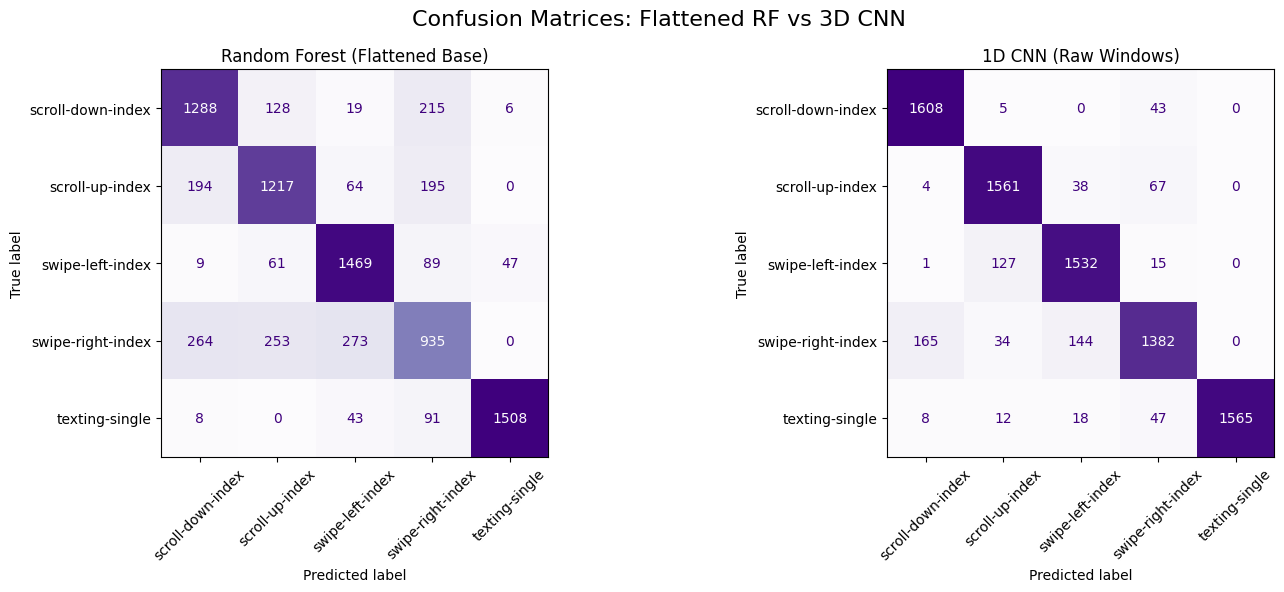

In [41]:
print("="*60)
print("🏆 K-FOLD HEAD-TO-HEAD RESULTS")
print("="*60)

for model_name, y_pred in all_y_pred.items():
    print(f"\n---> {model_name.upper()} <---")
    print(classification_report(all_y_true, y_pred, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Confusion Matrices: Flattened RF vs 3D CNN', fontsize=16)

for ax, (model_name, y_pred) in zip(axes, all_y_pred.items()):
    ConfusionMatrixDisplay.from_predictions(
        all_y_true, y_pred, ax=ax, cmap='Purples', colorbar=False, xticks_rotation=45
    )
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

## Leave-One-Subject-Out (LOSO) Cross-Validation

Unlike K-Fold which splits data chronologically within the same subjects,
LOSO evaluates true **cross-subject generalisation** — each fold holds out
one subject entirely and trains on the remaining two.

```
Fold 1: train=[02, 03]  val=[01]
Fold 2: train=[01, 03]  val=[02]
Fold 3: train=[01, 02]  val=[03]
```

This is the strictest evaluation protocol available given our cohort size,
as the model never sees any data from the test subject during training. Any performance
gap between K-Fold and LOSO directly quantifies how much the models were
relying on subject-specific signal characteristics rather than
gesture-discriminative patterns.

> **Note:** Because subject was really small (3) and recording conditions were not fully standardised
> (subjects varied in posture and phone-holding angle), LOSO performance
> is expected to drop significantly. A subject seated at a desk vs. on a
> couch produces a different IMU gravity baseline, causing the same gesture
> to look structurally different at the sensor level.

In [42]:
unique_users = ['01', '02', '03']
classification_results = {}
print(axes)

# default cleaning
gestures = chop_edges_and_concat(results)
# clean_nans(gestures)
cleaned_gestures = purge_outliers_all_gestures(gestures)

for holdout_user in unique_users:
    print(f"--- Running Fold: User {holdout_user} is Validation ---")
    
    fold_train = {gid: df[df['user'] != holdout_user].copy() for gid, df in cleaned_gestures.items()}
    fold_val = {gid: df[df['user'] == holdout_user].copy() for gid, df in cleaned_gestures.items()}
    
    y_true, y_pred = process_fold(fold_train, fold_val, ws=300)
    
    classification_results[holdout_user] = {'true': y_true, 'pred': y_pred}
    
        

# print("gestures_train keys: ", gestures_train.keys(), "\nlength: ", len(gestures_train))
# print("gestures_val keys: ", gestures_val.keys(), "\nlength: ", len(gestures_val))
# print("Example X_train shape: ", gestures_train['scroll-up-index'])

[<Axes: title={'center': 'Random Forest (Flattened Base)'}, xlabel='Predicted label', ylabel='True label'>
 <Axes: title={'center': '1D CNN (Raw Windows)'}, xlabel='Predicted label', ylabel='True label'>]
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
--- Running Fold: User 01 is Validation ---
--- Running Fold: User 02 is Validation ---
--- Running Fold: User 03 is Validation ---


## LOSO Cross-Validation Results — RF vs. 1D CNN

### Overall Performance

| Model | Accuracy | Macro F1 |
|---|---|---|
| Random Forest (Flattened) | 28% | 0.29 |
| 1D CNN (Raw Windows) | 42% | 0.43 |

Both models drop substantially compared to K-Fold (RF: 77%→28%, CNN: 91%→43%),
confirming that a significant portion of K-Fold performance was driven by
subject-specific signal patterns rather than gesture-discriminative features.
The CNN generalises better (+15pp over RF), but at 43% it is still only
modestly above random chance for a 5-class problem (20% baseline).

---

### Per-Class Breakdown

| Class | RF F1 | CNN F1 | Δ |
|---|---|---|---|
| Scroll Down | 0.46 | 0.61 | +0.15 |
| Scroll Up | 0.16 | 0.33 | +0.17 |
| Swipe Left | 0.19 | 0.36 | +0.17 |
| Swipe Right | 0.12 | 0.31 | +0.19 |
| Texting | 0.50 | ~0.53 | +0.03 |

**Texting** remains the most stable class across both models and both 
protocols — its irregular micro-movement fingerprint is distinct en

🏆 FINAL LOSO-CV HEAD-TO-HEAD RESULTS

---> RANDOM FOREST (FLATTENED BASE) <---
                   precision    recall  f1-score   support

scroll-down-index       0.46      0.46      0.46      1725
  scroll-up-index       0.14      0.19      0.16      1740
 swipe-left-index       0.18      0.20      0.19      1747
swipe-right-index       0.14      0.11      0.12      1797
   texting-single       0.58      0.43      0.50      1721

         accuracy                           0.28      8730
        macro avg       0.30      0.28      0.29      8730
     weighted avg       0.30      0.28      0.28      8730


---> 1D CNN (RAW WINDOWS) <---
                   precision    recall  f1-score   support

scroll-down-index       0.58      0.65      0.61      1725
  scroll-up-index       0.28      0.41      0.33      1740
 swipe-left-index       0.33      0.39      0.36      1747
swipe-right-index       0.34      0.28      0.31      1797
   texting-single       0.90      0.38      0.53      1721


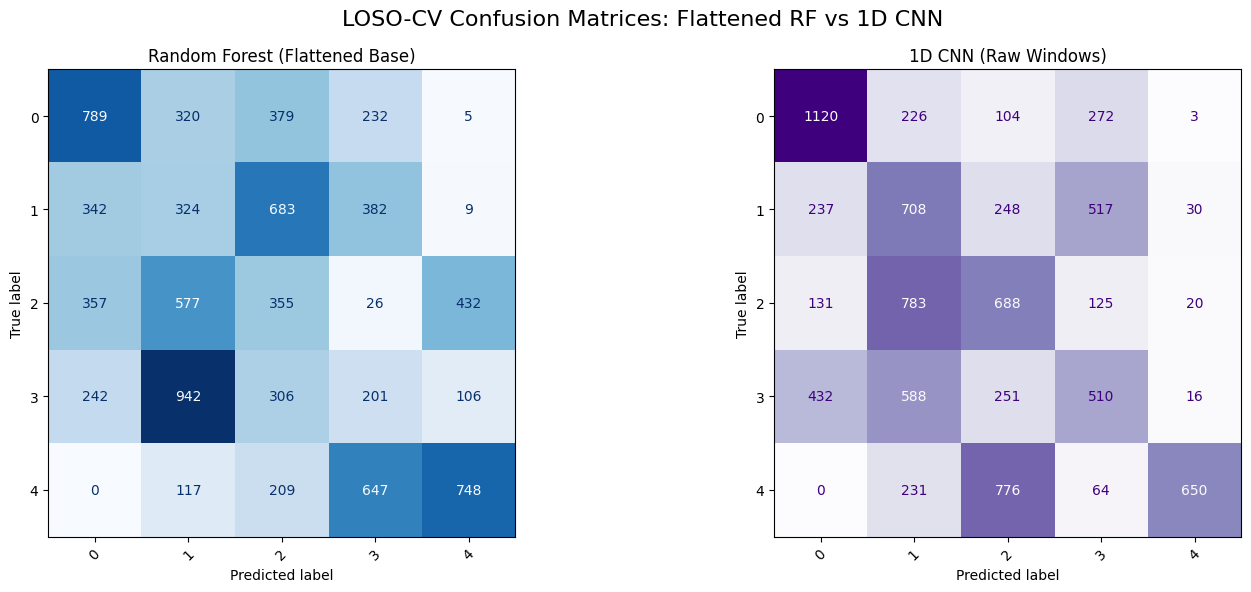

In [43]:
# Combine all true labels
final_true = np.concatenate([res['true'] for res in classification_results.values()])

# Extract predictions separately for both models
final_pred_rf = np.concatenate([res['pred']["Random Forest (Flattened Base)"] for res in classification_results.values()])
final_pred_cnn = np.concatenate([res['pred']["1D CNN (Raw Windows)"] for res in classification_results.values()])

all_final_preds = {
    "Random Forest (Flattened Base)": final_pred_rf,
    "1D CNN (Raw Windows)": final_pred_cnn
}

print("="*60)
print("🏆 FINAL LOSO-CV HEAD-TO-HEAD RESULTS")
print("="*60)

for model_name, final_pred in all_final_preds.items():
    print(f"\n---> {model_name.upper()} <---")
    print(classification_report(final_true, final_pred, zero_division=0))

# Plot Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('LOSO-CV Confusion Matrices: Flattened RF vs 1D CNN', fontsize=16)

for ax, (model_name, final_pred) in zip(axes, all_final_preds.items()):
    conf_matrix = confusion_matrix(final_true, final_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
    
    # Using different colormaps to tell them apart easily (Blues for RF, Purples for CNN)
    cmap = 'Blues' if 'Forest' in model_name else 'Purples'
    disp.plot(ax=ax, cmap=cmap, colorbar=False, xticks_rotation=45)
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

## Hyperparameter Tuning — Random Forest (Randomised Search)

Hyperparameter tuning is performed using **Randomised Search CV** rather 
than Exhaustive Grid Search. As shown by Bergstra & Bengio (2012), random 
search finds equally good or better hyperparameter configurations in a 
fraction of the time, particularly when only a few parameters meaningfully 
affect performance, random search spends more of its budget exploring those 
dimensions rather than exhaustively evaluating all combinations.

The search explores 50 randomly sampled configurations from the following 
parameter space, each scored via internal 5-fold cross-validation:

| Parameter | Candidates |
|---|---|
| `n_estimators` | 10, 25, 50, 75, 100, 150 |
| `max_depth` | None, 5, 10, 15, 20 |
| `min_samples_split` | 2, 5, 10 |
| `min_samples_leaf` | 1, 2, 4 |
| `bootstrap` | True, False |

The full grid has **540 possible combinations** — random search evaluates 
50 of them (≈9%), each with 5-fold CV, for a total of 250 model fits 
instead of 2700. `n_jobs=-1` parallelises across all available cores.

> While the parameter space here is modest, random search still avoids the combinatorial explosion of full grid enumeration and is adopted as standard practice.

> **Bergstra, J. & Bengio, Y. (2012).** Random Search for Hyper-Parameter 
> Optimization. *Journal of Machine Learning Research*, 13, 281–305.

In [49]:
# hyperparemeter tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_base = RandomForestClassifier(random_state=42)

# n_iter=50 means it will randomly test 50 different combinations
# cv=5 means it will use 5-fold cross-validation internally to score them
random_search = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_dist, 
    n_iter=50, 
    cv=5, 
    verbose=2, 
    random_state=42, 
    n_jobs=-1  # used all cores
)

full_features_dict, _ = window_and_filter_gestures(cleaned_gestures, ws=300, overlap=50, order=5, wn=0.4)
full_features_flat = flatten_gestures(full_features_dict)

X_full, y_full = prepare_xy(full_features_flat)

print("Starting Random Search...")
random_search.fit(X_full, y_full)

print("\n"+"="*50)
print("🏆 BEST PARAMETERS FOUND:")
print("="*50)
print(random_search.best_params_)
print(f"Best Internal CV Accuracy: {random_search.best_score_ * 100:.2f}%")

Starting Random Search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=25; total time=   3.8s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=25; total time=   3.9s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=25; total time=   3.9s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=25; total time=   3.8s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=25; total time=   3.7s
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=25; total time=   2.4s
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=25; total time=   2.3s
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=25; t

## True Unseen Test Set Results — RF (Flattened)

| Accuracy | Macro F1 |
|---|---|
| 23% | 0.14 |

### Per-Class Breakdown

| Class | Precision | Recall | F1 |
|---|---|---|---|
| Scroll Down | 0.31 | 0.40 | 0.35 |
| Scroll Up | 0.00 | 0.00 | 0.00 |
| Swipe Left | 0.00 | 0.00 | 0.00 |
| Swipe Right | 0.25 | 0.68 | 0.37 |
| Texting | 0.00 | 0.00 | 0.00 |

The flattened RF essentially collapses on the unseen test subject, 
predicting almost exclusively **Scroll Down** and **Swipe Right** while 
completely ignoring the remaining three classes (F1 = 0.00). This is 
the most severe generalisation failure across all models and protocols.

The macro F1 of **0.14** is notably lower than the 23% accuracy suggests — 
the model achieves that accuracy not by correctly classifying most gestures, 
but by over-predicting the two classes it has any confidence in, which 
happen to have enough true positives to inflate the accuracy score. This 
is a textbook case of why macro F1 is the more honest metric for 
multi-class evaluation.

The result confirms that flattening raw windows into 1200-dimensional 
vectors (200 samples × 6 axes) and feeding them to a tree ensemble 
produces a representation that is entirely subject-specific — the model 
memorises the precise waveform shape of the training subjects' gestures 
rather than learning any transferable discriminative structure.

Loading fresh data...
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Scaling data...
Windowing and flattening raw data...
Training final RF baseline model on raw flattened data...

🏆 TRUE UNSEEN TEST SET RESULTS (RAW FLATTENED RF)
                   precision    recall  f1-score   support

scroll-down-index       0.31      0.40      0.35       336
  scroll-up-index       0.00      0.00      0.00       339
 swipe-left-index       0.00      0.00      0.00       294

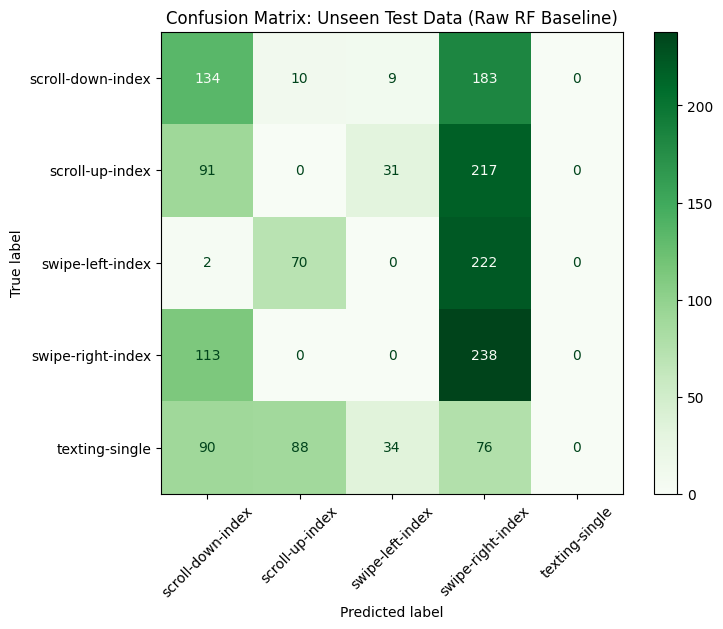

In [51]:
print("Loading fresh data...")
# Train Data
gestures_raw = chop_edges_and_concat(results)
train_clean = purge_outliers_all_gestures(gestures_raw)

# Test Data
test_raw = chop_edges_and_concat(test_results)
test_clean = purge_outliers_all_gestures(test_raw)

print("Scaling data...")
# Fits on train_clean, transforms both train_clean and test_clean safely in-place
scale_gestures(train_clean, test_clean)

print("Windowing and flattening raw data...")
clipped_train, _ = window_and_filter_gestures(train_clean, ws=300, overlap=50, order=5, wn=0.4, filter_type='lowpass')
clipped_test, _ = window_and_filter_gestures(test_clean, ws=300, overlap=50, order=5, wn=0.4, filter_type='lowpass')

train_clips_flat = flatten_gestures(clipped_train)
test_clips_flat = flatten_gestures(clipped_test)

X_train_flat, y_train_full = prepare_xy(train_clips_flat)
X_test_flat, y_test_full = prepare_xy(test_clips_flat)

print("Training final RF baseline model on raw flattened data...")
final_rf = RandomForestClassifier(**random_search.best_params_, random_state=42)
final_rf.fit(X_train_flat, y_train_full)

y_pred_test = final_rf.predict(X_test_flat)

print("\n" + "="*60)
print("🏆 TRUE UNSEEN TEST SET RESULTS (RAW FLATTENED RF)")
print("="*60)
print(classification_report(y_test_full, y_pred_test, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_full, y_pred_test, ax=ax, cmap='Greens', xticks_rotation=45)
plt.title("Confusion Matrix: Unseen Test Data (Raw RF Baseline)")
plt.show()

## True Unseen Test Set Results — 1D CNN

| Accuracy | Macro F1 |
|---|---|
| 52% | 0.48 |

### Per-Class Breakdown

| Class | Precision | Recall | F1 |
|---|---|---|---|
| Scroll Down | 0.57 | 0.70 | 0.63 |
| Scroll Up | 0.42 | 0.46 | 0.44 |
| Swipe Left | 0.04 | 0.01 | 0.01 |
| Swipe Right | 0.45 | 0.77 | 0.57 |
| Texting | 0.96 | 0.61 | 0.74 |

The CNN is the strongest performer on the unseen test set at 52%, and 
the only model that maintains meaningful predictions across more than 
two classes — a significant improvement over the flattened RF (23%) 
and consistent with its LOSO score (43%).

**Texting** achieves the highest precision (0.96), meaning nearly every 
window the model labels as Texting truly is one. The lower recall (0.61) 
suggests the model misses some Texting windows, likely classifying them 
as one of the directional gestures — but it never falsely floods other 
classes with Texting predictions.

**Swipe Right** has the highest recall (0.77) but modest precision (0.45), 
meaning the model over-predicts this class and absorbs windows that 
actually belong to other gestures. This is a common pattern for 
right-dominant subjects whose resting wrist position biases the IMU 
toward swipe-right-like readings.

**Swipe Left** collapses entirely (F1 = 0.01), consistent with its poor 
LOSO performance. This gesture appears to be the most subject-dependent 
in our dataset — the wrist rotation trajectory for a leftward swipe varies 
more between individuals than any other gesture, and with only three training 
subjects the CNN never generalises it reliably.

Overall, the CNN's unseen test performance demonstrates that learned 
temporal filters transfer partially across subjects, but the model still 
falls well short of production-ready accuracy — a predictable outcome 
given a training cohort of three subjects under uncontrolled conditions.

Loading fresh data for CNN...
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Scaling data...
Extracting 3D windows...
Training final CNN and predicting on unseen test data (this may take a moment)...

🏆 TRUE UNSEEN TEST SET RESULTS (CNN)
                   precision    recall  f1-score   support

scroll-down-index       0.57      0.70      0.63       336
  scroll-up-index       0.42      0.46      0.44       339
 swipe-left-index       0.04      0.01      0.01   

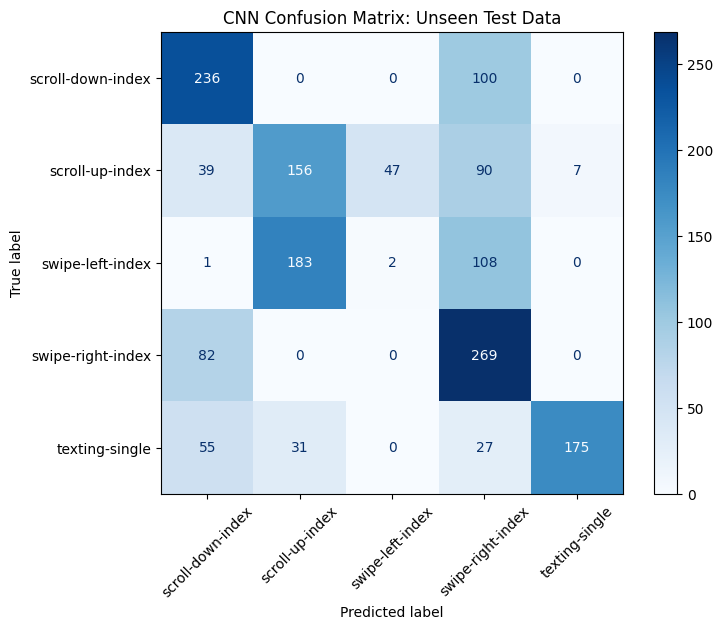

In [ ]:
# ---------------------------------------------------------
# CNN EVALUATION ON UNSEEN TEST DATA
# ---------------------------------------------------------
print("Loading fresh data for CNN...")
# Train Data
gestures_raw = chop_edges_and_concat(results)
train_clean = purge_outliers_all_gestures(gestures_raw)

# Test Data
test_raw = chop_edges_and_concat(test_results)
test_clean = purge_outliers_all_gestures(test_raw)

# Scale Data
print("Scaling data...")
scale_gestures(train_clean, test_clean)

# Window and filter gestures (for 3D shape)
print("Extracting 3D windows...")
clipped_train, _ = window_and_filter_gestures(train_clean, ws=300, overlap=50, order=5, wn=0.4, filter_type='lowpass')
clipped_test, _ = window_and_filter_gestures(test_clean, ws=300, overlap=50, order=5, wn=0.4, filter_type='lowpass')

# Prepare X, y in 3D format
X_train_3d, y_train_cnn = prepare_xy_3d(clipped_train)
X_test_3d, y_test_cnn = prepare_xy_3d(clipped_test)

# Train and Predict CNN
print("Training final CNN and predicting on unseen test data (this may take a moment)...")
y_pred_cnn = train_and_predict_cnn(X_train_3d, X_test_3d, y_train_cnn, y_test_cnn, epochs=20, batch_size=16)

print("\n" + "="*60)
print("🏆 TRUE UNSEEN TEST SET RESULTS (CNN)")
print("="*60)
print(classification_report(y_test_cnn, y_pred_cnn))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test_cnn, y_pred_cnn, ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("CNN Confusion Matrix: Unseen Test Data")
plt.show()


#### After observing the performance drop on the unseen test set, we investigated whether the degradation was caused by a unit mismatch or gravity baseline shift between the training and test recordings

In [ ]:
print("================ DIAGNOSTIC CHECK ================")

gesture = 'texting-single'

# 1. CHECK GRAVITY UNITS
train_z = train_clean[gesture]['acc_z'].mean()
test_z = test_clean[gesture]['acc_z'].mean()
print(f"1. UNITS CHECK:")
print(f"   Train 'Texting' Gravity (Z-axis): {train_z:.2f}")
print(f"   Test  'Texting' Gravity (Z-axis): {test_z:.2f}")
if abs(train_z - test_z) > 3.0:
    print("   -> 🚨 ALARM: Your units don't match! (9.8 vs 1.0 issue)")

# 2. CHECK SAMPLING RATE
train_len = len(train_clean[gesture])
test_len = len(test_clean[gesture])
print(f"\n2. SAMPLING RATE CHECK:")
print(f"   Train '{gesture}' total samples: {train_len}")
print(f"   Test  '{gesture}' total samples: {test_len}")
print("   -> (If you recorded 1 minute of test data, it should be exactly 6,000 samples at 100Hz)")

# 3. CHECK MAGNITUDE (Energy / Return Motions)
train_eng = train_clean['swipe-left-index']['gyr_z'].abs().mean()
test_eng = test_clean['swipe-left-index']['gyr_z'].abs().mean()
print(f"\n3. ENERGY CHECK (Are test gestures messier?):")
print(f"   Train 'Swipe Left' Gyro Energy: {train_eng:.2f}")
print(f"   Test  'Swipe Left' Gyro Energy: {test_eng:.2f}")

In [ ]:
for id in gestures_raw.keys():
    # Choose a gesture to inspect
    target_gesture = id

    # Grab 200 samples (2 seconds) from the middle of the clean datasets
    train_sample = train_clean[target_gesture].iloc[0:200] 
    test_sample = test_clean[target_gesture].iloc[0:200]   

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot Train
    axes[0].plot(train_sample['acc_x'].values, label='Acc X')
    axes[0].plot(train_sample['acc_y'].values, label='Acc Y')
    axes[0].plot(train_sample['acc_z'].values, label='Acc Z')
    axes[0].set_title(f"TRAIN Data: {target_gesture}")
    axes[0].legend()

    # Plot Test
    axes[1].plot(test_sample['acc_x'].values, label='Acc X')
    axes[1].plot(test_sample['acc_y'].values, label='Acc Y')
    axes[1].plot(test_sample['acc_z'].values, label='Acc Z')
    axes[1].set_title(f"TEST Data: {target_gesture}")
    axes[1].legend()

    plt.show()